In [1]:
import os, sys
from pathlib import Path
import pandas as pd

HERE = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
LEVEL1 = HERE.parent

if str(LEVEL1) not in sys.path:
    sys.path.insert(0, str(LEVEL1))
    
from argparse import ArgumentParser
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import torch
import math
import numpy as np

from data.synthetic import sim_data
from estimation.ecm import ECM_update
from models.dps import DPS
from training.early_stopping import EarlyStopping
from training.trainer import *
from training.loss import spline_penalty_loss
from data.dataset import Dataset

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc

def create_loaders(X_train, y_train, X_val, y_val, batch_size=None):
    bs = batch_size if batch_size else len(X_train)
    
    train_ds = TensorDataset(X_train, y_train)
    val_ds = TensorDataset(X_val, y_val)
    
    train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=len(X_val), shuffle=False) # Val 通常不需要 shuffle
    return train_loader, val_loader

def df2tensor_bike(df):
    X_df = df.iloc[:, :-1]   
    y_df = df.iloc[:, -1]    
    
    X_np = X_df.values
    y_np = y_df.values
    
    X_tensor = torch.from_numpy(X_np).float()
    y_tensor = torch.from_numpy(y_np).float() 
    
    return X_tensor, y_tensor.view(-1, 1)

In [2]:
case = 'churn'
task = 'classification' if case == 'churn' else 'regression'

data_loader = Dataset(case)
data = data_loader.get_data()
X_train, X_val, X_test = data['X_train'], data['X_val'], data['X_test']
y_train, y_val, y_test = data['y_train'], data['y_val'], data['y_test']
bs = 2048

print(X_train.size())
train_loader, val_loader = create_loaders(X_train, y_train, X_val, y_val, batch_size = bs)

torch.Size([5625, 19])


### DPS

In [44]:
ndim = X_train.size()[1]; nk = 10; Fout = 1; learning_rate = 1e-2; ECM_iteration = 20

hidden_config = [64, 8]
nbl = len(hidden_config)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device = "cpu"
criterion = torch.nn.MSELoss(reduction='mean')

DeepBS = DPS(input_dim = ndim, degree = 3, num_knots = nk, num_neurons = hidden_config, num_bsl = nbl, dropout = 0.2, output_dim = Fout, knots_place = 'quantile', bias = True).to(device)

optimizer = torch.optim.Adam(DeepBS.parameters(), lr=learning_rate)

save_path_bs = f"best_DBS_model_{case}_test.pt"
early_stop = EarlyStopping(patience=50, verbose=False, delta=1e-3, path=save_path_bs)

In [ ]:
trainer = Trainer(DeepBS, optimizer, criterion, device, early_stopping=early_stop)
trainer.fit(train_loader, val_loader, epochs=10000)

Training:   0%|          | 0/3 [00:00<?, ?it/s]

In [41]:
with torch.no_grad():
    DeepBS = DPS(input_dim = ndim, degree = 3, num_knots = nk, num_neurons = hidden_config, num_bsl = len(hidden_config), dropout = 0.2, output_dim = Fout, knots_place = 'quantile', bias = True).to(device)
    DeepBS.load_state_dict(torch.load(save_path_bs, weights_only=True))
    DeepBS.eval()
    
    if task == 'classification':
        pred_train_probs = torch.sigmoid(DeepBS(X_train))
        pred_test_probs = torch.sigmoid(DeepBS(X_test))
        
        fpr, tpr, thresholds = roc_curve(y_train, pred_train_probs.detach().numpy())
        print(f"(DPS) Training AUC: {auc(fpr, tpr):.4f}")
        fpr, tpr, thresholds = roc_curve(y_test, pred_test_probs.detach().numpy())
        print(f"(DPS) Testing AUC: {auc(fpr, tpr):.4f}")
        
    else:
        print(f"(DPS) Training MSE: {criterion(DeepBS(X_train), y_train):.4f}")
        print(f"(DPS) Testing MSE: {criterion(DeepBS(X_test), y_test):.4f}")

(DPS) Training AUC: 0.8458
(DPS) Testing AUC: 0.8521


In [42]:
y_train.sum()

tensor(1495.)

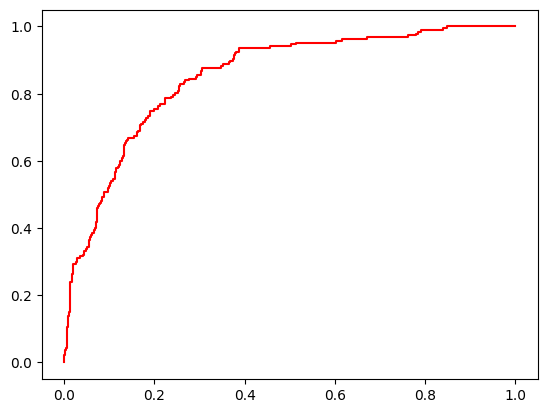

In [43]:
(y_test == torch.where(pred_test_probs > 0.5, 1, 0)).sum()/704
import matplotlib.pyplot as plt 
plt.plot(fpr, tpr, label='Random Forest',color = "r")


## Manual

In [ ]:
ndim = X_train.size()[1]
nk = 15
hidden_config = [256, 128, 64]
nbl = len(hidden_config)
dp = 0.2
Fout = 1
device = 'cpu'
hp = '_B'
save_path_bs = "./best_model/best_DBS_model_"+case+ hp + ".pt"
save_path_bs = "./old_model_file/best_DBS_model_bikeA.pt"

criterion = torch.nn.MSELoss(reduction='mean')
ECM_iteration = 20

with torch.no_grad():
    DeepBS = DPS(input_dim = ndim, degree = 3, num_knots = nk, num_neurons = hidden_config, num_bsl = nbl, dropout = dp, output_dim = Fout, knots_place = 'quantile', bias = True).to(device)
    DeepBS.load_state_dict(torch.load(save_path_bs, weights_only=True))
    DeepBS.eval()
    
    print(f"Training MSE: {criterion(DeepBS(X_train), y_train):.4f}")
    print(f"Testing MSE: {criterion(DeepBS(X_test), y_test):.4f}")

In [9]:
Info_ECM['Best_Lambda']

tensor([0.0478, 0.0610, 0.0499])

In [22]:
sub_sample_ECM = 1024 # It should be whole dataset
with torch.no_grad():
    DeepBS = DPS(input_dim = ndim, degree = 3, num_knots = nk, num_neurons = hidden_config, num_bsl = nbl, dropout = dp, output_dim = Fout, knots_place = 'quantile', bias = True).to(device)
    DeepBS.load_state_dict(torch.load(save_path_bs, weights_only=True))
    Info_ECM, iteration = ECM_update(DeepBS, ECM_iteration, X_train[:sub_sample_ECM,:], y_train[:sub_sample_ECM], True)
    

GCV: 0.3508773744106293
GCV: 0.3508749306201935
GCV Converge at 2 iteration


In [23]:
DeepPS = DPS(input_dim = ndim, degree = 3, num_knots = nk, num_neurons = hidden_config, num_bsl = nbl, dropout = 0.0, output_dim = Fout, knots_place = 'quantile', bias = True).to(device)
DeepPS.load_state_dict(torch.load(save_path_bs, weights_only=True))
optimizer = torch.optim.Adam(DeepPS.parameters(), lr=1e-3)
save_path_ps = f"best_DPS_model_{case}_test.pt"

early_stop = EarlyStopping(patience=50, verbose=False, delta=1e-4, path=save_path_ps)

In [24]:
trainer = Trainer(DeepPS, optimizer, criterion, device, early_stopping=early_stop)
trainer.fit(train_loader, val_loader, epochs=100, penalty_func = spline_penalty_loss, lambda_vals = Info_ECM['Best_Lambda'])

Epochs:  38%|███▊      | 38/100 [01:13<01:59,  1.93s/it, Train=11.1125, Val=0.3755]


KeyboardInterrupt: 

In [25]:
with torch.no_grad():
    DeepPS = DPS(input_dim = ndim, degree = 3, num_knots = nk, num_neurons = hidden_config, num_bsl = nbl, dropout = 0.1, output_dim = Fout, knots_place = 'quantile', bias = True).to(device)
    DeepPS.load_state_dict(torch.load(save_path_ps, weights_only=True))
    DeepPS.eval()

    score_train_ps = criterion(y_train, DeepPS(X_train)).item()
    score_ps = criterion(y_test, DeepPS(X_test)).item()
    print(f"(After Adding Penalty) DPS Training MSE: {score_train_ps:.4f} | Testing MSE: {score_ps:.4f}")

(After Adding Penalty) DPS Training MSE: 0.2598 | Testing MSE: 0.3116


### Benchmark - Churn/ Bike/ CA

In [8]:
from dnamite.models import DNAMiteBinaryClassifier
model = DNAMiteBinaryClassifier()
model.fit(pd.DataFrame(X_train), y_train.view(-1))

from sklearn.metrics import roc_curve, auc
pred_test_probs = model.predict(pd.DataFrame(X_test))
fpr, tpr, thresholds = roc_curve(y_test, pred_test_probs)
print(f"(DBS) Testing AUC: {auc(fpr, tpr):.4f}")

,n_embed,32
,n_hidden,32
,n_layers,2
,max_bins,32
,min_samples_per_bin,None
,validation_size,0.2
,n_val_splits,5
,learning_rate,0.0005
,max_epochs,100
,batch_size,128
,device,'cpu'


In [22]:
X_train_np, y_train_np = to_numpy(X_train), to_numpy(y_train)
X_val_np, y_val_np = to_numpy(X_val), to_numpy(y_val)
X_test_np, y_test_np = to_numpy(X_test), to_numpy(y_test)

print(f"Data Shapes - Train: {X_train_np.shape}, Val: {X_val_np.shape}, Test: {X_test_np.shape}")

# ==========================================
# 1. XGBoost (The Black-box Gold Standard)
# ==========================================
print("\n--- Training XGBoost ---")
# 參數設定：這是工業界標準起手式，兼顧速度與精度
xgb_model = xgb.XGBRegressor(
    n_estimators=2000,      # 給足夠的樹
    learning_rate=0.05,     # 較小的學習率以獲得更佳精度
    max_depth=6,            # 標準深度
    n_jobs=-1,              # 平行運算
    objective='reg:squarederror',
    tree_method='hist',     # 對大數據集 (YearPrediction) 加速極快
    device="cuda" if torch.cuda.is_available() else "cpu", # 如果有 GPU 可加速
    early_stopping_rounds = 50
)

# 關鍵：使用 Validation Set 做 Early Stopping
xgb_model.fit(
    X_train_np, y_train_np,
    eval_set=[(X_val_np, y_val_np)],
    verbose=100
)

y_pred_xgb = xgb_model.predict(X_test_np)
mse_xgb = get_mse(y_test_np, y_pred_xgb)
print(f"XGBoost Test MSE: {mse_xgb:.4f}")


'''
# ==========================================
# 2. EBM (Explainable Boosting Machine)
# ==========================================
print("\n--- Training EBM (InterpretML) ---")
# 注意：EBM 在 YearPrediction (50萬筆) 上訓練會比較慢，這是正常的
# 如果記憶體不足，可以調整 outer_bags 或 interactions
ebm = ExplainableBoostingRegressor(
    outer_bags=8,         # 默認是 8，調低可以加速但精度會降
    inner_bags=0,         # 默認是 0
    learning_rate=0.01,
    interactions=10,      # 自動偵測 10 組交互作用
    n_jobs=-1
)

ebm.fit(X_train_np, y_train_np) 
# EBM 內部有自己的 Validation 機制，通常不需要手動傳 eval_set

y_pred_ebm = ebm.predict(X_test_np)
mse_ebm = get_mse(y_test_np, y_pred_ebm)
print(f"EBM Test MSE: {mse_ebm:.4f}")
'''


'''
# ==========================================
# 3. DNN (Deep Neural Network Baseline)
# ==========================================
print("\n--- Training DNN (PyTorch) ---")
# 一個標準的 3-Layer MLP，用來代表"如果不考慮可解釋性，純 NN 能做到多少"

class SimpleDNN(nn.Module):
    def __init__(self, input_dim):
        super(SimpleDNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256), # 加速收斂
            nn.Dropout(0.1),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 1)
        )
        
    def forward(self, x):
        return self.net(x)

# 準備 Tensor (確保在 GPU 上)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = 'cpu'
X_train_t = X_train.to(device).float()
y_train_t = y_train.to(device).float()
X_val_t = X_val.to(device).float()
y_val_t = y_val.to(device).float()
X_test_t = X_test.to(device).float()

model_dnn = SimpleDNN(X_train.shape[1]).to(device)
optimizer = optim.Adam(model_dnn.parameters(), lr=0.001)
criterion = nn.MSELoss()

# 簡單的 Training Loop with Early Stopping
best_val_loss = float('inf')
patience = 20
counter = 0

batch_size = 1024 # 大數據集建議大 Batch
train_dataset = torch.utils.data.TensorDataset(X_train_t, y_train_t)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

for epoch in range(100): # 設 100 epoch，通常很快就會 Early stop
    model_dnn.train()
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model_dnn(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
    
    # Validation
    model_dnn.eval()
    with torch.no_grad():
        val_preds = model_dnn(X_val_t)
        val_loss = criterion(val_preds, y_val_t).item()
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Val Loss: {val_loss:.4f}")
        
    # Early Stopping Check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model_dnn.state_dict(), 'best_dnn.pth')
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

# Load Best Model & Predict
model_dnn.load_state_dict(torch.load('best_dnn.pth'))
model_dnn.eval()
with torch.no_grad():
    y_pred_dnn = model_dnn(X_test_t).cpu().numpy()

mse_dnn = get_mse(y_test_np, y_pred_dnn)
print(f"DNN Test MSE: {mse_dnn:.4f}")


# ==========================================
# 4. LassoNet (Feature Selection SOTA)
# ==========================================
print("\n--- Training LassoNet ---")
# LassoNet 結合了 NN 的非線性與 LASSO 的特徵選擇
# 適合用來比較"稀疏性 (Sparsity)"

lasso_net = LassoNetRegressor(
    hidden_dims=(256, 128),
    lambda_start='auto', # 自動尋找 lambda 路徑
    verbose=True,
    device=device,
    patience=(10, 3) # (path_patience, val_patience)
)

# LassoNet 需要 validation data 來選擇最佳 lambda
lasso_net.path(X_train_t, y_train_t, X_val=X_val_t, y_val=y_val_t)

# LassoNet 會自動存儲整條路徑上最好的模型
y_pred_lasso = lasso_net.predict(X_test_t)
mse_lasso = get_mse(y_test_np, y_pred_lasso)
print(f"LassoNet Test MSE: {mse_lasso:.4f}")


# ==========================================
# Summary
# ==========================================
print("\n=== Benchmark Results ===")
print(f"XGBoost  : {mse_xgb:.4f}")
#print(f"EBM      : {mse_ebm:.4f}")
print(f"DNN      : {mse_dnn:.4f}")
print(f"LassoNet : {mse_lasso:.4f}")
'''

Data Shapes - Train: (11122, 12), Val: (2781, 12), Test: (3476, 12)

--- Training XGBoost ---
[0]	validation_0-rmse:178.62205
[100]	validation_0-rmse:50.44273
[200]	validation_0-rmse:44.33017
[300]	validation_0-rmse:43.12463
[400]	validation_0-rmse:42.52396
[500]	validation_0-rmse:41.86619
[600]	validation_0-rmse:41.57629
[700]	validation_0-rmse:41.17255
[800]	validation_0-rmse:41.05995
[816]	validation_0-rmse:41.04933
XGBoost Test MSE: 1869.0651


/home/users/yhung7/.local/lib/python3.13/site-packages/xgboost/core.py:729: UserWarning: [16:36:12] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


'\n# ==========================================\n# 3. DNN (Deep Neural Network Baseline)\n# ==========================================\nprint("\n--- Training DNN (PyTorch) ---")\n# 一個標準的 3-Layer MLP，用來代表"如果不考慮可解釋性，純 NN 能做到多少"\n\nclass SimpleDNN(nn.Module):\n    def __init__(self, input_dim):\n        super(SimpleDNN, self).__init__()\n        self.net = nn.Sequential(\n            nn.Linear(input_dim, 256),\n            nn.ReLU(),\n            nn.BatchNorm1d(256), # 加速收斂\n            nn.Dropout(0.1),\n            nn.Linear(256, 128),\n            nn.ReLU(),\n            nn.BatchNorm1d(128),\n            nn.Linear(128, 1)\n        )\n\n    def forward(self, x):\n        return self.net(x)\n\n# 準備 Tensor (確保在 GPU 上)\ndevice = torch.device("cuda" if torch.cuda.is_available() else "cpu")\ndevice = \'cpu\'\nX_train_t = X_train.to(device).float()\ny_train_t = y_train.to(device).float()\nX_val_t = X_val.to(device).float()\ny_val_t = y_val.to(device).float()\nX_test_t = X_test.to(device).float

In [24]:
from sklearn.ensemble import RandomForestRegressor


regr = RandomForestRegressor(n_estimators=1000, random_state=0)
regr.fit(X_train_np, y_train_np)

print(get_mse(regr.predict(X_test_np), y_test_np))

/home/users/yhung7/.local/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[ 18.356  60.973  81.008 ... 173.9   209.57  100.082]


##

### Benchmark - Year

In [2]:
case = 'year'
data_loader = Dataset(case)
data = data_loader.get_data()
X_train, X_val, X_test = data['X_train'], data['X_val'], data['X_test']
y_train, y_val, y_test = data['y_train'], data['y_val'], data['y_test']
bs = 2048

print(X_train.size())
train_loader, val_loader = create_loaders(X_train, y_train, X_val, y_val, batch_size = bs)
test_loader, _ = create_loaders(X_test, y_test, X_test, y_test, batch_size = bs)

Loading YearPredictionMSD... this might take a minute.
Data Loaded.
Train size: 463715, Test size: 51630, Features: 90
torch.Size([417343, 90])


In [29]:
X_train_np, y_train_np = to_numpy(X_train), to_numpy(y_train)
X_val_np, y_val_np = to_numpy(X_val), to_numpy(y_val)
X_test_np, y_test_np = to_numpy(X_test), to_numpy(y_test)

print(f"Data Shapes - Train: {X_train_np.shape}, Val: {X_val_np.shape}, Test: {X_test_np.shape}")

# ==========================================
# 1. XGBoost (The Black-box Gold Standard)
# ==========================================
print("\n--- Training XGBoost ---")

xgb_model = xgb.XGBRegressor(
    n_estimators=2000,      # 給足夠的樹
    learning_rate=0.05,     # 較小的學習率以獲得更佳精度
    max_depth=6,            # 標準深度
    n_jobs=-1,              # 平行運算
    objective='reg:squarederror',
    tree_method='hist',     # 對大數據集 (YearPrediction) 加速極快
    device="cuda" if torch.cuda.is_available() else "cpu", # 如果有 GPU 可加速
    early_stopping_rounds = 50
)

# 關鍵：使用 Validation Set 做 Early Stopping
xgb_model.fit(
    X_train_np, y_train_np,
    eval_set=[(X_val_np, y_val_np)],
    verbose=100
)

y_pred_xgb = xgb_model.predict(X_test_np)
mse_xgb = get_mse(y_test_np, y_pred_xgb)
print(f"XGBoost Test MSE: {mse_xgb:.4f}")

Data Shapes - Train: (417343, 90), Val: (46372, 90), Test: (51630, 90)

--- Training XGBoost ---
[0]	validation_0-rmse:10.82161
[100]	validation_0-rmse:9.14407
[200]	validation_0-rmse:8.97960
[300]	validation_0-rmse:8.90589
[400]	validation_0-rmse:8.86443
[500]	validation_0-rmse:8.83493
[600]	validation_0-rmse:8.80931
[700]	validation_0-rmse:8.78999
[800]	validation_0-rmse:8.77192
[900]	validation_0-rmse:8.75718
[1000]	validation_0-rmse:8.74246
[1100]	validation_0-rmse:8.72957
[1200]	validation_0-rmse:8.71760
[1300]	validation_0-rmse:8.70707
[1400]	validation_0-rmse:8.69706
[1500]	validation_0-rmse:8.68930
[1600]	validation_0-rmse:8.68121
[1700]	validation_0-rmse:8.67405
[1800]	validation_0-rmse:8.66774
[1900]	validation_0-rmse:8.66125
[1999]	validation_0-rmse:8.65512
XGBoost Test MSE: 79.4335


In [ ]:
from sklearn.ensemble import RandomForestRegressor

X_train_np, y_train_np = to_numpy(X_train), to_numpy(y_train)
X_val_np, y_val_np = to_numpy(X_val), to_numpy(y_val)
X_test_np, y_test_np = to_numpy(X_test), to_numpy(y_test)


regr = RandomForestRegressor(n_estimators=1000, random_state=0)
regr.fit(X_train_np, y_train_np.ravel())

print(get_mse(regr.predict(X_test_np), y_test_np.ravel()))

In [18]:
nk = 10; Fout = 1; learning_rate = 1e-1
_, ndim = X_train.size()
hidden_config = [128, 64, 64]
nbl = len(hidden_config)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device = "cpu"
criterion = torch.nn.MSELoss(reduction='mean')

DeepBS = DPS(input_dim = ndim, degree = 3, num_knots = nk, num_neurons = hidden_config, num_bsl = nbl, dropout = 0.0, output_dim = Fout, knots_place = 'quantile', bias = True).to(device)

optimizer = torch.optim.Adam(DeepBS.parameters(), lr=learning_rate)

save_path_bs = f"best_DBS_model_YP.pt"
early_stop = EarlyStopping(patience=50, verbose=False, delta=1e-3, path=save_path_bs)

In [19]:
trainer = Trainer(DeepBS, optimizer, criterion, device, early_stopping=early_stop)
trainer.fit(train_loader, val_loader, epochs=10000)

Epochs:   0%|          | 11/10000 [02:59<45:11:39, 16.29s/it, Train=70.5254, Val=98.2589]


KeyboardInterrupt: 